In [1]:
# importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\rpran\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


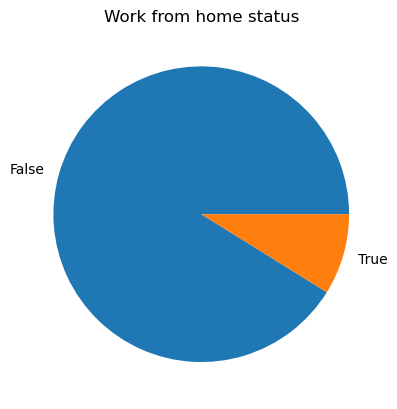

In [4]:
df['job_work_from_home'].value_counts().plot(kind='pie')
plt.ylabel('')
plt.title('Work from home status')
plt.show()

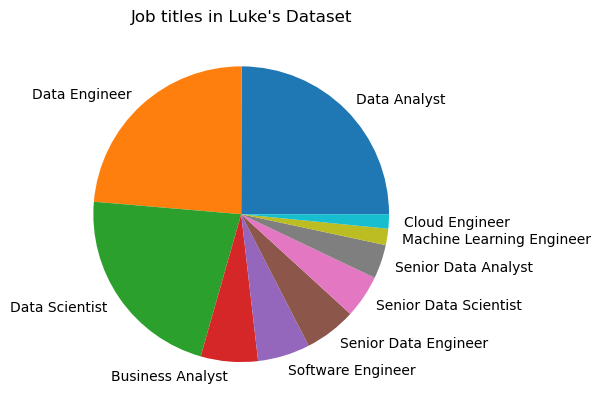

In [8]:
df['job_title_short'].value_counts().plot(kind='pie')
plt.ylabel('')
plt.title("Job titles in Luke's Dataset")
plt.show()

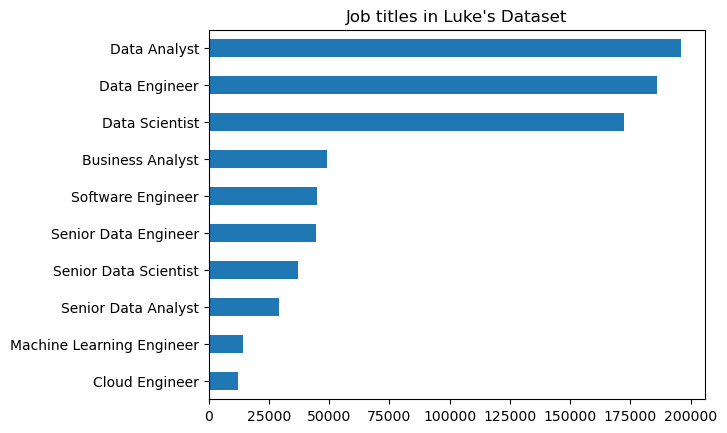

In [9]:
df['job_title_short'].value_counts().plot(kind='barh')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.title("Job titles in Luke's Dataset")
plt.show()

In [10]:
# when there is more contents to analyse it is best to use bar chart this is much more clear to understand

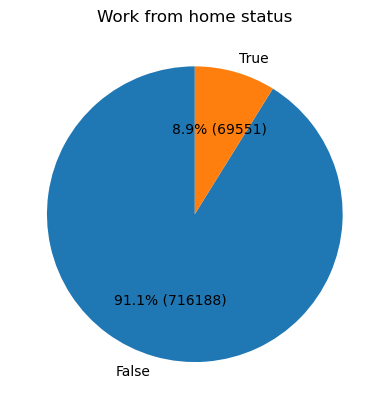

In [29]:
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct=lambda p: f"{p:.1f}% ({int(p/100 * df['job_work_from_home'].value_counts().sum())})")
plt.ylabel('')
plt.title('Work from home status')
plt.show()

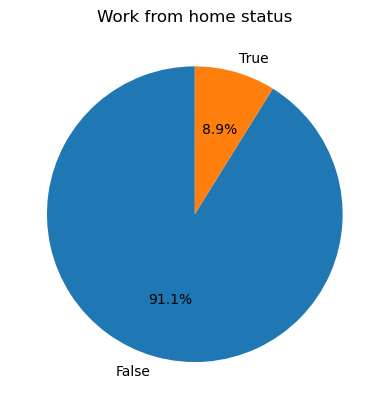

In [ ]:
# the above one is some advance stuff
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%')
plt.ylabel('')
plt.title('Work from home status')
plt.show()

In [31]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [32]:
df[['job_work_from_home','job_no_degree_mention','job_health_insurance']]

,job_work_from_home,job_no_degree_mention,job_health_insurance
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
...,...,...,...
785736,False,False,False
785737,False,False,False
785738,False,False,False
785739,False,False,False


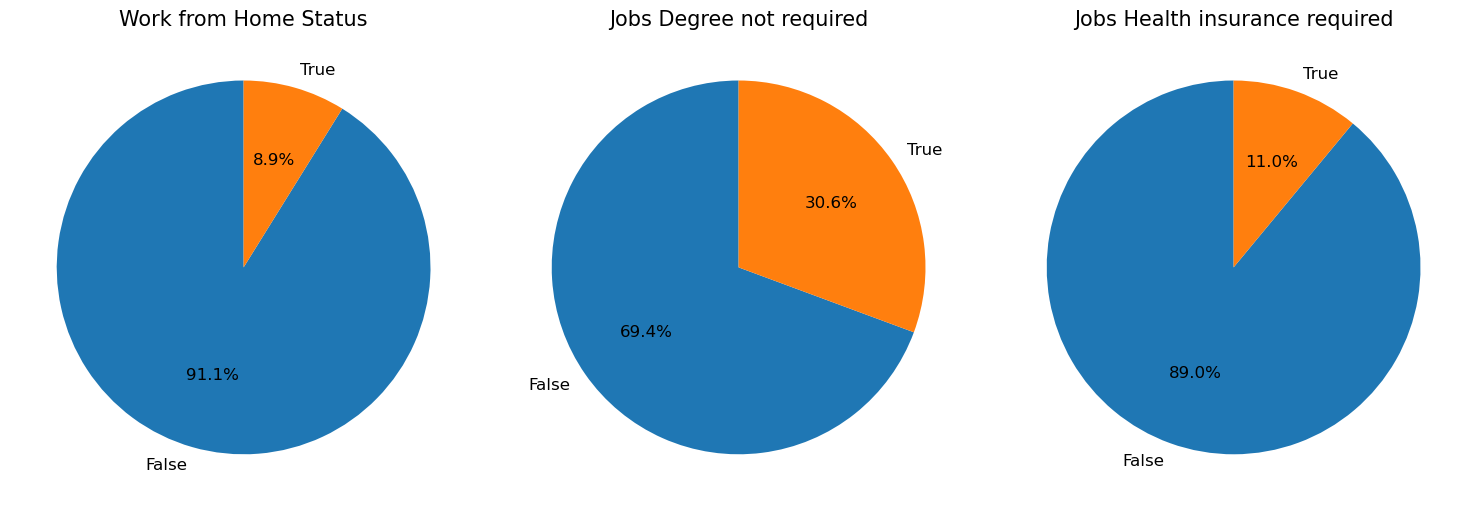

In [43]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

dict_columns ={
    'job_work_from_home': 'Work from Home Status',
    'job_no_degree_mention': 'Jobs Degree not required',
    'job_health_insurance': 'Jobs Health insurance required'
}

for i, (column, title) in enumerate(dict_columns.items()):
    ax[i].pie(df[column].value_counts(), startangle=90, autopct= '%1.1f%%', labels= ['False','True'], textprops={'fontsize': 12})
    ax[i].set_title(title, fontsize=15)
fig.tight_layout()
plt.show()